# Case Study — Knowledge graph Generation for Biomedical Abstracts
### IndabaX 2026

## Setup

In [1]:
# @title Install dependencies { display-mode: "form" }
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "datasets", "openai", "python-dotenv", "spacy",
    "sentence-transformers>=3.0", "networkx", "pyvis>=0.3.2",
    "matplotlib", "scipy"], check=True)
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"], check=True)
print("✅ packages ready")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ packages ready


In [2]:
# @title Setup { display-mode: "form" }
import sys, os, pathlib

_root = pathlib.Path.cwd()
if not (_root / "notebook_src").exists():
    for _p in sorted(_root.glob("*/notebook_src")):
        _root = _p.parent
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# ── API key (one-time demo) ──────────────────────────────────────────────
# Paste your OpenAI key between the quotes for the demo, then DELETE it after.
# Leave blank to fall back to a local .env file.
OPENAI_API_KEY = ""
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
elif not os.environ.get("OPENAI_API_KEY"):
    try:
        from dotenv import load_dotenv
        load_dotenv(_root / ".env")
    except ImportError:
        pass
API_KEY = os.environ.get("OPENAI_API_KEY", "")

# ── Model ────────────────────────────────────────────────────────────────
# gpt-4o-mini works on virtually any key; switch to gpt-4.1-nano (cheaper) or any
# chat model your key supports. This pipeline makes many LLM calls — mind the cost.
MODEL = "gpt-4o-mini"

print("✅ notebook_src ready —", _root)
print("🔑 OpenAI key:", "found" if API_KEY else "MISSING — paste it above or create a .env file")
print("🤖 Model:", MODEL)

✅ notebook_src ready — /Users/taineelliott/Documents/2026_NdabaX/collab notebook
🔑 OpenAI key: found
🤖 Model: gpt-4o-mini


In [3]:
# What this hands-on covers, end to end
from notebook_src.visuals import show
from notebook_src.display import render_4_1_roadmap
show(render_4_1_roadmap())

## Part 1 · The Corpus

<div style="border-left:4px solid #0d9488;background:#f0fdfa;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">📄 &nbsp;Part 1 · The Corpus</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Five same-domain abstracts on pancreatic cancer. One becomes the working example we take all the way to a knowledge graph.</div></div>

In [4]:
from notebook_src import pancreatic as P
from notebook_src.display import render_corpus, render_abstract

show(render_corpus(P.abstracts(), working=0))

# The working abstract — shown in the SAME paper-card representation as notebook 4.
working = P.working_abstract()
show(render_abstract(P.to_ex(working), working["title"], working["authors"],
                     working["journal"], working["year"]))

## Part 2 · Chunking the Abstract

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">✂️ &nbsp;Part 2 · Chunking the Abstract</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Two ways to break text into knowledge units: atomic PROPOSITIONS, and TRIPLES (open-domain vs ontology-based).</div></div>

### Proposition chunking

<div style="border-left:3px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🧩 &nbsp;Proposition chunking</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Decompose the abstract into atomic, single-fact statements (pronouns kept for now).</div></div>

In [5]:
from notebook_src.extraction import extract_propositions
from notebook_src.display import render_propositions

text  = P.full_text(working)
props = extract_propositions(text, API_KEY, model=MODEL)
show(render_propositions(props))

### The schema we're extracting (as a graph)

<div style="border-left:3px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🗺️ &nbsp;The schema we're extracting (as a graph)</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Before extracting anything, here is the ontology itself as a knowledge graph — the entity TYPES (nodes) and the typical relations we expect to populate. Triple extraction fills this schema with real instances.</div></div>

In [6]:
from notebook_src.display import render_kg

# The ontology as a KG: nodes are entity TYPES, edges are the schema-level relations.
show(render_kg(P.schema_triples(), strategy="Ontology Schema", color_by="type",
               group_colours=P.TYPE_COLOURS, height="420px"))

### Where does the OBIE schema come from?

<div style="border-left:3px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">📚 &nbsp;Where does the OBIE schema come from?</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">OBIE's categories must be fixed in advance. Ours is a curated slice of MeSH and UMLS — standard biomedical vocabularies from the U.S. National Library of Medicine.</div></div>

In [7]:
from notebook_src.display import render_obie_schema_source
show(render_obie_schema_source(P.PANCREATIC_ONTOLOGY))

### Triple chunking — OpenIE vs OBIE

<div style="border-left:3px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🔗 &nbsp;Triple chunking — OpenIE vs OBIE</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Open-domain extraction (schema-free) beside ontology-based extraction (anchored to the pancreatic-cancer MeSH ontology above).</div></div>

In [8]:
from notebook_src.extraction import extract_openie, extract_obie
from notebook_src.display import render_triples

contexts, labels = P.sections(working)

# Open-domain: every relationship, entity types guessed against our ontology.
openie = extract_openie(contexts, labels, API_KEY, model=MODEL,
                        ontology_types=P.PANCREATIC_ONTOLOGY)
show(render_triples(openie, strategy="OpenIE"))

# Ontology-based: triples anchored to the pancreatic MeSH concepts.
obie = extract_obie(contexts, labels, P.mesh_headings(), API_KEY, model=MODEL)
show(render_triples(obie, strategy="OBIE"))

SUBJECT,PREDICATE,OBJECT,CONF,SOURCE SENTENCE
Pancreatic ductal adenocarcinoma (PDAC),is the most common malignancy of,the pancreas,100%,Pancreatic ductal adenocarcinoma (PDAC) is the most common malignancy of the pan…
Pancreatic ductal adenocarcinoma (PDAC),is among the most lethal of,human cancers,100%,Pancreatic ductal adenocarcinoma (PDAC) is the most common malignancy of the pan…
Pancreatic ductal adenocarcinoma (PDAC),has a five-year survival of,roughly ten percent,100%,Pancreatic ductal adenocarcinoma (PDAC) is the most common malignancy of the pan…
tumour,arises from,ductal epithelium,90%,The tumour arises from the ductal epithelium and evolves through a series of non…
tumour,evolves through,series of non-invasive precursor lesions,80%,The tumour arises from the ductal epithelium and evolves through a series of non…
series of non-invasive precursor lesions,called,pancreatic intraepithelial neoplasia (PanIN),95%,The tumour arises from the ductal epithelium and evolves through a series of non…
lesions,progress,invasive disease,100%,"As these lesions progress, they accumulate an expanding set of genetic alteratio…"
lesions,accumulate,an expanding set of genetic alterations,100%,"As these lesions progress, they accumulate an expanding set of genetic alteratio…"
an expanding set of genetic alterations,culminate in,invasive disease,100%,"As these lesions progress, they accumulate an expanding set of genetic alteratio…"
Activating point mutations in the KRAS oncogene,are detectable in,about ninety percent of cases,90%,Activating point mutations in the KRAS oncogene are detectable in about ninety p…


SUBJECT,PREDICATE,OBJECT,CONF,SOURCE SENTENCE
Pancreatic ductal adenocarcinoma,is part of,pancreas,80%,Pancreatic ductal adenocarcinoma (PDAC) is the most common malignancy of the pan…
Pancreatic ductal adenocarcinoma,is associated with,human cancers,70%,Pancreatic ductal adenocarcinoma (PDAC) is the most common malignancy of the pan…
tumour,arises from,ductal epithelium,80%,The tumour arises from the ductal epithelium and evolves through a series of non…
Pancreatic Intraepithelial Neoplasia,is part of,a series of non-invasive precursor lesions,90%,The tumour arises from the ductal epithelium and evolves through a series of non…
KRAS oncogene,is part of,tumour-cell proliferation,80%,Activating point mutations in the KRAS oncogene are detectable in about ninety p…
inactivation of the tumour-suppressor genes CDKN2A,is part of,tumours,80%,Progression is then driven by inactivation of the tumour-suppressor genes CDKN2A…
inactivation of the tumour-suppressor genes TP53,is part of,tumours,80%,Progression is then driven by inactivation of the tumour-suppressor genes CDKN2A…
inactivation of the tumour-suppressor genes SMAD4,is part of,tumours,80%,Progression is then driven by inactivation of the tumour-suppressor genes CDKN2A…
SMAD4,is associated with,widely metastatic pattern of spread,80%,Immunohistochemical loss of SMAD4 in particular correlates with a widely metasta…
cancer-associated fibroblasts,is part of,desmoplastic stroma,80%,Surrounding the malignant cells is a dense desmoplastic stroma of cancer-associa…


### OpenIE vs OBIE — the structural difference

<div style="border-left:3px solid #1d4ed8;background:#eff6ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🔬 &nbsp;OpenIE vs OBIE — the structural difference</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">The same kind of fact, extracted two ways: an open-domain triple carries a GUESSED entity type; an ontology-based triple is ANCHORED to a fixed MeSH concept.</div></div>

In [9]:
from notebook_src.display import render_ie_structure_compare

# Pick a representative triple from each (one that actually carries its tag).
openie_ex = next((t for t in openie if t.get("subject_type")), openie[0]) if openie else {}
obie_ex   = next((t for t in obie   if t.get("subject_mesh")), obie[0])   if obie   else {}
show(render_ie_structure_compare(openie_ex, obie_ex))

## Part 3 · Validate — Back-translation & Calibration

<div style="border-left:4px solid #1d4ed8;background:#eff6ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🔁 &nbsp;Part 3 · Validate — Back-translation & Calibration</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Reconstruct the abstract from a representation and measure the round-trip. A raw cosine is only meaningful once you calibrate it — across THREE models.</div></div>

### Back-translation

<div style="border-left:3px solid #1d4ed8;background:#eff6ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">↩️ &nbsp;Back-translation</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Turn triples back into prose. If the meaning survived, the reconstruction should be close to the original.</div></div>

In [10]:
from notebook_src.validation import back_translate, text_cosine, BIOMED_MODEL
from notebook_src.display import render_abstract_comparison

reconstructed = back_translate(openie, API_KEY, model=MODEL)
sim = text_cosine(text, reconstructed, model_name=BIOMED_MODEL)
show(render_abstract_comparison(text, reconstructed, sim, model_name="BioLORD"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### What does a cosine score mean? — three models

<div style="border-left:3px solid #1d4ed8;background:#eff6ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">📏 &nbsp;What does a cosine score mean? — three models</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">The same STS-B benchmark under a general, a biomedical and a legal model. Our 5 abstracts' round-trip score is marked on each scale.</div></div>

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

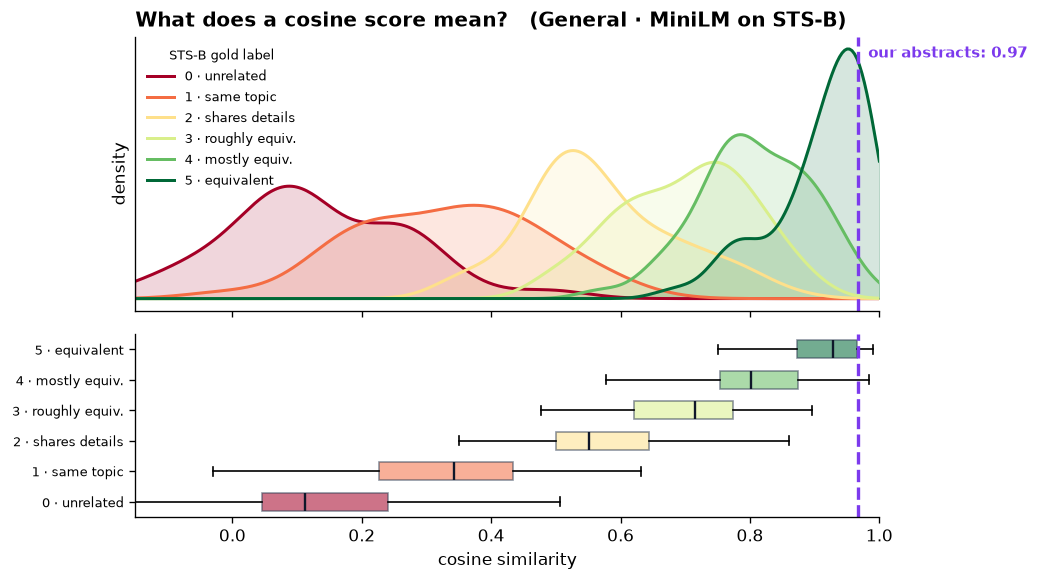

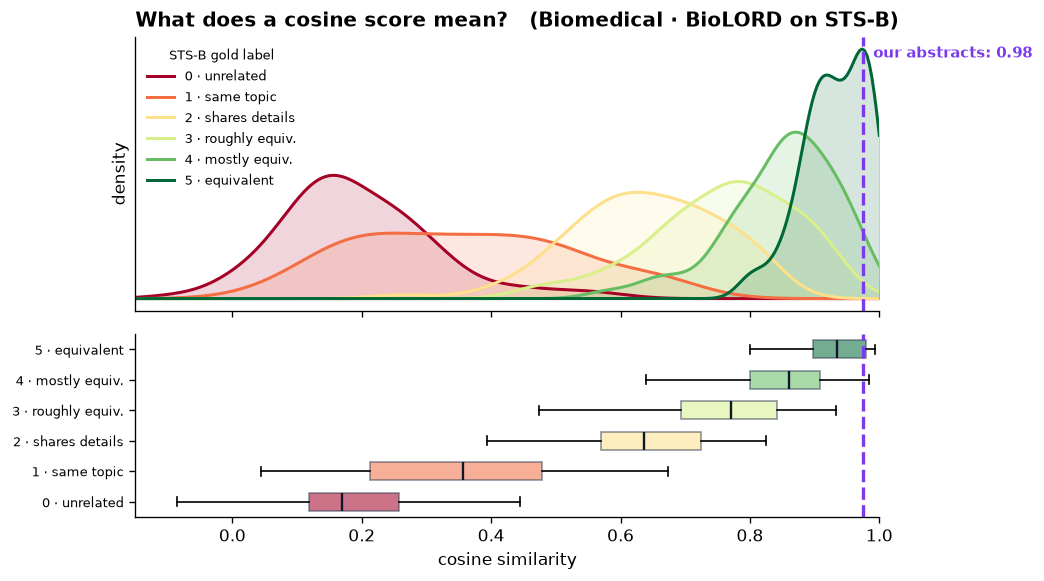

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


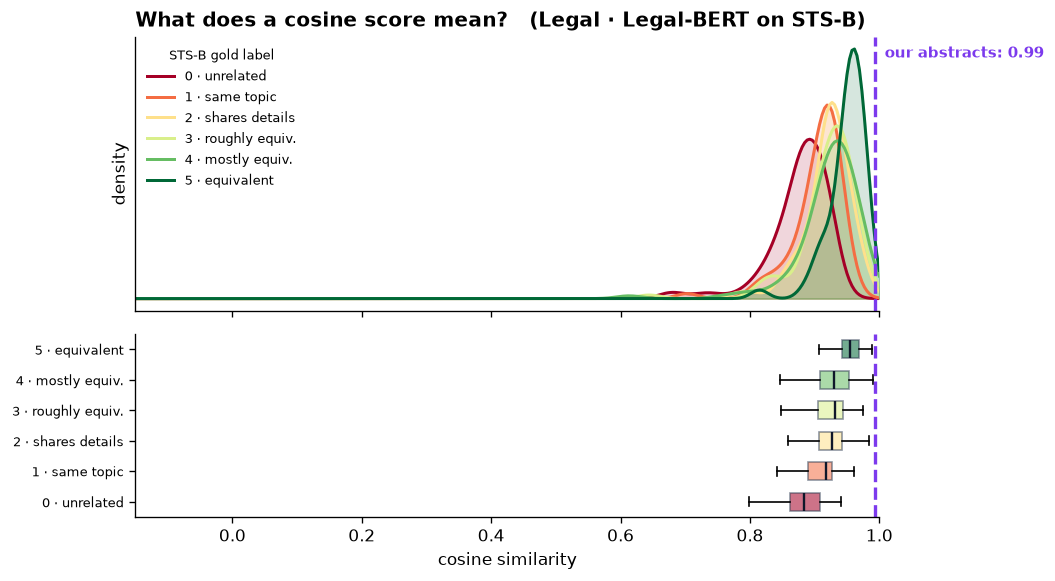

In [11]:
import numpy as np
from notebook_src.extraction import extract_propositions
from notebook_src.validation import (CALIBRATION_MODELS, stsb_cosine_by_category,
    plot_calibration, back_translate_statements, text_cosine)

# Round-trip all 5 abstracts (cheap: proposition reconstruction) for the highlight.
roundtrips = []
for a in P.abstracts():
    t  = P.full_text(a)
    ap = props if a is P.abstracts()[0] else extract_propositions(t, API_KEY, model=MODEL)
    roundtrips.append((t, back_translate_statements(ap, API_KEY, model=MODEL)))

# One calibration plot per model (general → biomedical → legal), each highlighting
# the mean cosine of OUR abstracts' round-trip under that model.
cat_by_model, highlights = {}, {}
for label, mname in CALIBRATION_MODELS.items():
    cat = stsb_cosine_by_category(max_pairs=500, model_name=mname)
    hl  = float(np.mean([text_cosine(o, r, model_name=mname) for o, r in roundtrips]))
    plot_calibration(cat, highlight=hl, highlight_label="our abstracts", model_name=label)
    cat_by_model[label], highlights[label] = cat, hl

### Compare 1 — the three models on one axis

<div style="border-left:3px solid #1d4ed8;background:#eff6ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">⚖️ &nbsp;Compare 1 — the three models on one axis</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Same relatedness, different cosine. A domain model with no STS tuning (legal) compresses everything high — its cosine is hard to read.</div></div>

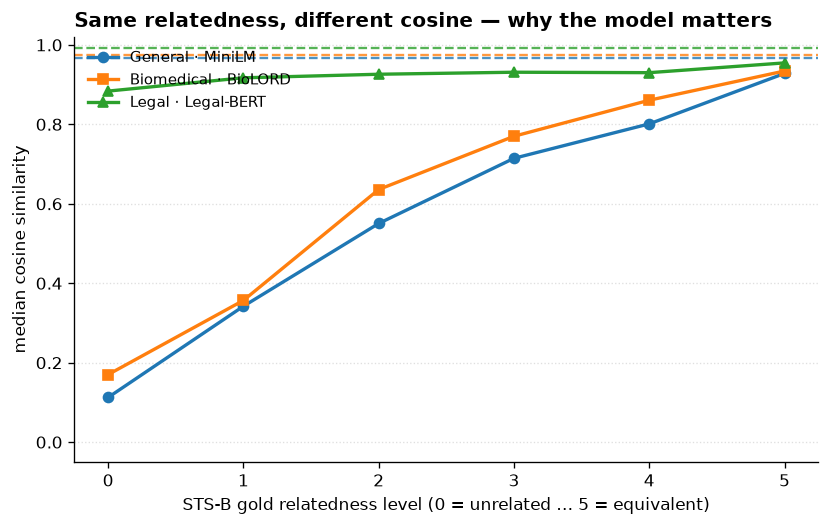

In [12]:
from notebook_src.validation import plot_model_comparison
plot_model_comparison(cat_by_model, highlights=highlights)

### Compare 2 — which representation preserved the meaning?

<div style="border-left:3px solid #1d4ed8;background:#eff6ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🧪 &nbsp;Compare 2 — which representation preserved the meaning?</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Back-translate each chunking representation and score its fidelity: propositions vs OpenIE triples vs OBIE triples.</div></div>

In [13]:
from notebook_src.validation import representation_fidelity
from notebook_src.display import render_representation_compare

reps = [
    {"name": "Propositions",   "kind": "propositions", "items": props},
    {"name": "OpenIE triples", "kind": "triples",      "items": openie},
    {"name": "OBIE triples",   "kind": "triples",      "items": obie},
]
fidelity = representation_fidelity(text, reps, API_KEY, model_name=BIOMED_MODEL, model=MODEL)
show(render_representation_compare(fidelity))

## Part 4 · Coreference Resolution

<div style="border-left:4px solid #0d9488;background:#f0fdfa;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🔗 &nbsp;Part 4 · Coreference Resolution</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Our propositions still say 'it' and 'they'. Resolve every reference to the explicit entity, so each proposition stands on its own.</div></div>

In [14]:
from notebook_src.extraction import resolve_coreferences
from notebook_src.display import render_coref

resolved = resolve_coreferences(props, API_KEY, model=MODEL, context=text)
show(render_coref(props, resolved))

## Part 5 · Triples from the Propositions

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">⚙️ &nbsp;Part 5 · Triples from the Propositions</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Because each proposition is atomic and self-contained, extraction is cleaner. Every triple keeps its source proposition.</div></div>

In [15]:
from notebook_src.extraction import triples_from_propositions
from notebook_src.display import render_triples, render_proposition_schema

prop_triples = triples_from_propositions(resolved, API_KEY, model=MODEL,
                                         ontology_types=P.PANCREATIC_ONTOLOGY)

# The SCHEMA these triples follow: ontological TYPES on the entities, and the
# source PROPOSITION embedded inside the relationship (concepts are added in Part 6).
show(render_proposition_schema(prop_triples[0] if prop_triples else None))

# The triples themselves.
show(render_triples(prop_triples, strategy="OpenIE"))
print("Each triple's provenance is the proposition it came from, e.g.:")
print(" •", prop_triples[0]["sentences"][0] if prop_triples else "(none)")

SUBJECT,PREDICATE,OBJECT,CONF,SOURCE SENTENCE
Pancreatic ductal adenocarcinoma (PDAC),be,the most common malignancy,100%,Pancreatic ductal adenocarcinoma (PDAC) is the most common malignancy of the pan…
the most common malignancy,of,the pancreas,100%,Pancreatic ductal adenocarcinoma (PDAC) is the most common malignancy of the pan…
Pancreatic ductal adenocarcinoma (PDAC),is among the most lethal of,human cancers,90%,Pancreatic ductal adenocarcinoma (PDAC) is among the most lethal of human cancer…
five-year survival rate,is,roughly ten percent,100%,The five-year survival rate of pancreatic ductal adenocarcinoma (PDAC) is roughl…
five-year survival rate,of,pancreatic ductal adenocarcinoma (PDAC),100%,The five-year survival rate of pancreatic ductal adenocarcinoma (PDAC) is roughl…
pancreatic ductal adenocarcinoma (PDAC),is,ten percent,90%,The five-year survival rate of pancreatic ductal adenocarcinoma (PDAC) is roughl…
tumour of pancreatic ductal adenocarcinoma (PDAC),arises from,ductal epithelium,100%,The tumour of pancreatic ductal adenocarcinoma (PDAC) arises from the ductal epi…
tumour of pancreatic ductal adenocarcinoma (PDAC),evolves through,series of non-invasive precursor lesions,90%,The tumour of pancreatic ductal adenocarcinoma (PDAC) evolves through a series o…
series of non-invasive precursor lesions,called,pancreatic intraepithelial neoplasia (PanIN),90%,The tumour of pancreatic ductal adenocarcinoma (PDAC) evolves through a series o…
pancreatic ductal adenocarcinoma (PDAC),has precursor lesions,pancreatic intraepithelial neoplasia (PanIN),80%,The tumour of pancreatic ductal adenocarcinoma (PDAC) evolves through a series o…


Each triple's provenance is the proposition it came from, e.g.:
 • Pancreatic ductal adenocarcinoma (PDAC) is the most common malignancy of the pancreas.


## Part 6 · Entity Mapping — Bridging Synonyms

<div style="border-left:4px solid #b45309;background:#fffbeb;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🧬 &nbsp;Part 6 · Entity Mapping — Bridging Synonyms</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">Ground every entity to a concept. Watch the many surface forms of the disease — PDAC, adenocarcinoma, cancer of the pancreas — bridge to ONE concept.</div></div>

In [16]:
from notebook_src.extraction import ground_to_mesh
from notebook_src.graph import canonicalize_triples
from notebook_src.display import render_grounding, render_disambiguation

# (a) Ground each entity to a concept — every surface form of the disease
#     (PDAC, adenocarcinoma, cancer of the pancreas) bridges to one concept.
typed, rows = ground_to_mesh(prop_triples, P.mesh_headings(),
                             m2t=P.mesh_to_type(), allowed_types=P.type_names(),
                             synonyms=P.synonyms())
show(render_grounding(rows))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ENTITY,LLM GUESS,NEAREST MeSH,SIMILARITY,→ ONTOLOGY TYPE
CDKN2A,Gene or Protein (UMLS T028),CDKN2A gene,1.00,Gene or Protein
Immunohistochemical loss of SMAD4,Neoplastic Process,SMAD4 gene,1.00,Gene or Protein
KRAS activation,Gene or Protein,KRAS gene,1.00,Gene or Protein
KRAS mutations,Gene or Protein,KRAS gene,1.00,Gene or Protein
KRAS oncogene,Gene or Protein,KRAS gene,1.00,Gene or Protein
Pancreatic ductal adenocarcinoma (PDAC),Neoplastic Process,Pancreatic Neoplasms,1.00,Neoplastic Process
SMAD4,Gene or Protein (UMLS T028),SMAD4 gene,1.00,Gene or Protein
TP53,Gene or Protein,TP53 gene,1.00,Gene or Protein
a large fraction of pancreatic ductal adenocarcinoma (PDAC) tumours,Neoplastic Process (UMLS T191),Pancreatic Neoplasms,1.00,Neoplastic Process
cancer-associated fibroblasts,Cell,Cancer-Associated Fibroblasts,1.00,Cell


In [17]:
# 🔎 The bridge: every surface form of the disease now points at ONE concept.
for r in rows:
    if r["mapped_type"] == "Neoplastic Process":
        print(f'{r["entity"]:32s} -> {r["mesh"]}  ({r["via"]})')

# (b) Merge those surface forms into a single canonical node.
kg_triples, clusters, (n_before, n_after) = canonicalize_triples(typed, threshold=0.9)
show(render_disambiguation(clusters, n_before, n_after))

Pancreatic ductal adenocarcinoma (PDAC) -> Pancreatic Neoplasms  (synonym)
a large fraction of pancreatic ductal adenocarcinoma (PDAC) tumours -> Pancreatic Neoplasms  (synonym)
fraction of pancreatic ductal adenocarcinoma tumours -> Pancreatic Neoplasms  (synonym)
genetic trajectory of pancreatic ductal adenocarcinoma -> Pancreatic Neoplasms  (synonym)
genetic trajectory of pancreatic ductal adenocarcinoma (PDAC) -> Pancreatic Neoplasms  (synonym)
pancreatic ductal adenocarcinoma -> Pancreatic Neoplasms  (synonym)
pancreatic ductal adenocarcinoma (PDAC) -> Pancreatic Neoplasms  (synonym)
pancreatic ductal adenocarcinoma (PDAC) tumours -> Pancreatic Neoplasms  (synonym)
pancreatic ductal adenocarcinoma tumours -> Pancreatic Neoplasms  (synonym)
pancreatic intraepithelial neoplasia (PanIN) -> Pancreatic Intraepithelial Neoplasia  (synonym)
the progression of pancreatic ductal adenocarcinoma -> Pancreatic Neoplasms  (synonym)
tumour of pancreatic ductal adenocarcinoma (PDAC) -> Pancreati

CANONICAL NODE,MERGED SURFACE FORMS,
pancreatic ductal adenocarcinoma (PDAC),Pancreatic ductal adenocarcinoma (PDAC)tumour of pancreatic ductal adenocarcinoma (PDAC),3 forms
pancreatic ductal adenocarcinoma,pancreatic ductal adenocarcinoma (PDAC) tumourspancreatic ductal adenocarcinoma tumours,3 forms
desmoplastic stroma,dense desmoplastic stroma,2 forms
large fraction,a large fraction,2 forms


## Part 7 · The Final Knowledge Graph

<div style="border-left:4px solid #0d9488;background:#f0fdfa;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🕸️ &nbsp;Part 7 · The Final Knowledge Graph</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">One graph: PROPOSITIONS live inside the edges (hover an edge), CONCEPTS live on the entities (hover a node). This is the structure you'll reuse in Hands-on B.</div></div>

In [18]:
from notebook_src.graph import build_graph, graph_stats
from notebook_src.display import render_kg_pair, render_graph_stats, render_proposition_schema

# Reminder of what every edge and node in the final graph carries — now with the
# grounded CONCEPT filled in by Part 6's entity mapping.
show(render_proposition_schema(kg_triples[0] if kg_triples else None))

# Before vs after entity mapping: raw proposition-triples (varied surface forms,
# LLM-guessed types) → grounded to concepts and merged into canonical nodes.
show(render_kg_pair(prop_triples, kg_triples,
                    left_title="Before entity mapping",
                    right_title="After entity mapping (grounded + merged)",
                    color_by="type", group_colours=P.TYPE_COLOURS, height="460px"))

kg = build_graph(kg_triples)
show(render_graph_stats(graph_stats(kg)))

## Part 8 · Now Apply It to a Murder

<div style="border-left:4px solid #b91c1c;background:#fef2f2;border-radius:0 10px 10px 0;padding:13px 18px;margin-top:4px;margin-bottom:10px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0f172a;">🔪 &nbsp;Part 8 · Now Apply It to a Murder</div><div style="font-size:12px;color:#475569;margin-top:3px;line-height:1.5">You just built a proposition-grounded knowledge graph from scientific text. In Hands-on B you use the very same logic to solve a crime.</div></div>

In [19]:
from notebook_src.display import render_points_card
show(render_points_card("Bridge", "Same pipeline, new domain",
    "What you built here transfers directly to Hands-on B", [
    "<b>Chunk</b> the source into propositions and triples — text becomes knowledge units.",
    "<b>Validate</b> the extraction — back-translation + a calibrated similarity score.",
    "<b>Resolve coreference</b> so every unit stands alone.",
    "<b>Map entities to concepts</b> — bridge synonyms to one node.",
    "<b>Build the graph</b> — propositions in the edges, concepts on the entities — then "
    "reason over it. In Hands-on B, that reasoning names a murderer.",
], grad="135deg,#7f1d1d,#b91c1c"))

## References

**Chunking & extraction**
- [Chen et al. (2023) — Dense X Retrieval: What Retrieval Granularity Should We Use? (proposition chunking)](https://arxiv.org/abs/2312.06648)
- Banko et al. (2007) — Open Information Extraction from the Web (IJCAI) · Wimalasuriya & Dou (2010) — Ontology-Based Information Extraction: A Survey

**Validation & similarity**
- [Cer et al. (2017) — SemEval-2017 STS Benchmark](https://arxiv.org/abs/1708.00055)
- [Reimers & Gurevych (2019) — Sentence-BERT (EMNLP)](https://arxiv.org/abs/1908.10084) · [Wang et al. (2020) — MiniLM (NeurIPS)](https://arxiv.org/abs/2002.10957)

**Biomedical ontology & embeddings**
- [MeSH — Medical Subject Headings (NLM)](https://www.nlm.nih.gov/mesh/) · [UMLS — Bodenreider (2004), NLM](https://www.nlm.nih.gov/research/umls/)
- [BioLORD — Remy et al. (2023)](https://huggingface.co/FremyCompany/BioLORD-2023-C) · [LEGAL-BERT — Chalkidis et al. (2020)](https://arxiv.org/abs/2010.02559)

**Models & tools**
- [OpenAI API](https://platform.openai.com/docs) · [Hugging Face Datasets](https://huggingface.co/docs/datasets) · [sentence-transformers](https://www.sbert.net) · [NetworkX](https://networkx.org) · [pyvis](https://pyvis.readthedocs.io)

*The five pancreatic-cancer abstracts are hand-authored for teaching from established facts — illustrative, not real papers.*
